In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import tensorflow.keras as kr
import numpy as np
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D , Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [9]:
path , dir , files = next(os.walk("/content/drive/MyDrive/Datasets/Brain_Data_Organised/Stroke"))
file_count = len(files)
print(f"Stroke: {file_count}")

Stroke: 950


In [10]:
path , dir , files = next(os.walk("/content/drive/MyDrive/Datasets/Brain_Data_Organised/Normal"))
file_count = len(files)
print(f"Normal: {file_count}")

Normal: 1551


In [11]:
image_size = (224 , 224)
batch_size = 32

train_df = kr.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Datasets/Brain_Data_Organised/train",
    validation_split = 0.20,
    subset = "training",
    seed = 1337,
    image_size = image_size,
    batch_size = batch_size
)

val_df = kr.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Datasets/Brain_Data_Organised/train",
    validation_split = 0.20,
    subset = "validation",
    seed = 1337,
    image_size = image_size,
    batch_size = batch_size
)

test_df =  kr.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Datasets/Brain_Data_Organised/test",
    image_size = image_size,
    batch_size = batch_size,
    shuffle = False
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Found 501 files belonging to 2 classes.


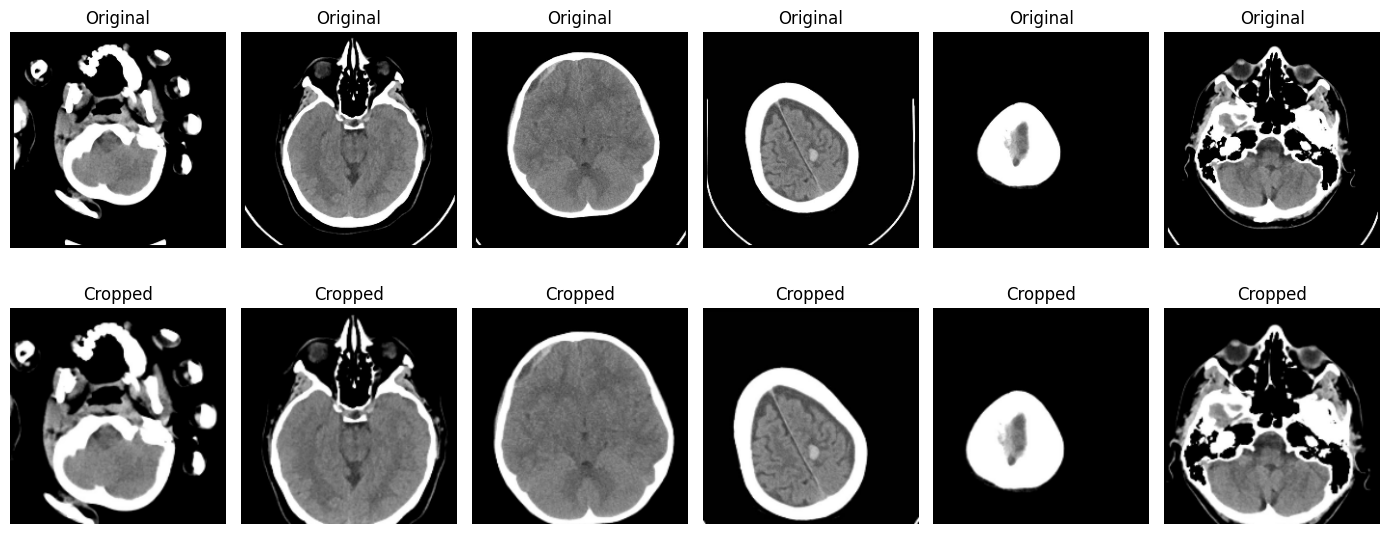

In [12]:
# ============================================================
# 1) دالة القص (Crop) - هتتحط في نفس الخلية بتاعت الـ Data Pipeline
#    قبل ما تعمل .map() عليها للـ train/val/test
# ============================================================
import tensorflow as tf
import matplotlib.pyplot as plt

def crop_borders(image, label, bottom_frac=0.15, side_frac=0.08, target_size=(224, 224)):
    """
    يشيل نسبة من تحت الصورة (فين بيظهر الـ Arc annotation) ونسبة من الجانبين،
    وبعدين يعمل Resize تاني لنفس الـ target_size عشان الموديل ياخد نفس شكل الـ Input.

    bottom_frac: نسبة الجزء المقصوص من تحت (0.15 = 15% من ارتفاع الصورة)
    side_frac:   نسبة الجزء المقصوص من كل جانب (0.08 = 8% من عرض الصورة من كل ناحية)
    """
    img_shape = tf.shape(image)
    h, w = img_shape[1], img_shape[2]   # <-- [1] و [2] لإن الـ Tensor شكله [Batch, Height, Width, Channels]

    bottom_crop = tf.cast(tf.cast(h, tf.float32) * bottom_frac, tf.int32)
    side_crop = tf.cast(tf.cast(w, tf.float32) * side_frac, tf.int32)

    new_height = h - bottom_crop
    new_width = w - 2 * side_crop

    cropped = tf.image.crop_to_bounding_box(
        image,
        offset_height=0,          # نفضل من فوق زي ما هو
        offset_width=side_crop,   # نشيل من الشمال
        target_height=new_height, # نشيل من تحت (لإننا مبدأناش من فوق)
        target_width=new_width    # نشيل من اليمين كمان (نفس قيمة side_crop)
    )

    cropped = tf.image.resize(cropped, target_size)
    return cropped, label


# ============================================================
# 2) Preview - جرب النسب دي الأول قبل ما تطبقها على كل الداتاست
#    شغّل الخلية دي وشوف هل القص شايل الـ Arc كويس من غير ما ياكل من المخ
# ============================================================
def preview_crop(dataset, bottom_frac=0.15, side_frac=0.08, num_images=6):
    plt.figure(figsize=(14, 6))
    # بنعمل Shuffle بدون seed ثابت في كل مرة، عشان الباتش اللي بنجيبه يبقى
    # عشوائي مختلف كل مرة تشغّل فيها الفانكشن، مش نفس أول باتش دايمًا
    shuffled_dataset = dataset.shuffle(buffer_size=200)

    for images, labels in shuffled_dataset.take(1):
        cropped_images, _ = crop_borders(images, labels, bottom_frac, side_frac)
        for i in range(min(num_images, images.shape[0])):
            # الصورة الأصلية
            plt.subplot(2, num_images, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title("Original")
            plt.axis("off")

            # الصورة بعد القص
            plt.subplot(2, num_images, num_images + i + 1)
            plt.imshow(cropped_images[i].numpy().astype("uint8"))
            plt.title("Cropped")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

# جرب كذا نسبة مختلفة وشوف أنهي واحدة بتشيل الـ Arc كويس:
preview_crop(train_df, bottom_frac=0.15, side_frac=0.08)
# preview_crop(train_df, bottom_frac=0.20, side_frac=0.10)  # جرب نسبة أعلى لو لسه باين


# ============================================================
# 3) بعد ما تستقر على النسبة المناسبة، طبقها على الـ 3 Datasets
#    (القص نفسه، مش الـ Augmentation، بيتطبق على train/val/test الثلاثة
#     لإنه جزء من الـ Preprocessing مش من الـ Augmentation)
# ============================================================
BOTTOM_FRAC = 0.15   # <-- عدّل الرقم ده بعد ما تشوف نتيجة الـ Preview
SIDE_FRAC = 0.08

train_df = train_df.map(lambda x, y: crop_borders(x, y, BOTTOM_FRAC, SIDE_FRAC))
val_df = val_df.map(lambda x, y: crop_borders(x, y, BOTTOM_FRAC, SIDE_FRAC))
test_df = test_df.map(lambda x, y: crop_borders(x, y, BOTTOM_FRAC, SIDE_FRAC))


# ============================================================
# 4) Strong Augmentation - يتطبق على train_df بس (مش val ولا test)
#    بيجمع بين: Rotation / Zoom / Translation / Contrast + Cutout عشوائي
# ============================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.15),         # لحد تقريبًا ±54 درجة (كانت 0.08 = ±29 درجة)
    tf.keras.layers.RandomFlip("horizontal"),      # قلب أفقي (يمين/شمال) بشكل عشوائي
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.15),
], name="strong_augmentation")


def random_cutout_batch(images, labels, mask_size=40, prob=0.5):
    """
    بيغطي مربع عشوائي في الصورة بلون أسود، بشكل عشوائي لكل صورة لوحدها.
    الهدف: يمنع الموديل من الاعتماد على مكان ثابت في الصورة (زي الـ Arc)
    لإنه هيتغطي أحيانًا، فالموديل يضطر يتعلم ملامح المخ نفسها.
    """
    img_h = tf.shape(images)[1]
    img_w = tf.shape(images)[2]

    def apply_cutout(img):
        do_cutout = tf.random.uniform([]) < prob

        def cutout():
            y = tf.random.uniform([], 0, img_h, dtype=tf.int32)
            x = tf.random.uniform([], 0, img_w, dtype=tf.int32)
            y1 = tf.maximum(0, y - mask_size // 2)
            y2 = tf.minimum(img_h, y + mask_size // 2)
            x1 = tf.maximum(0, x - mask_size // 2)
            x2 = tf.minimum(img_w, x + mask_size // 2)

            mask = tf.pad(
                tf.zeros((y2 - y1, x2 - x1), dtype=tf.float32),
                paddings=[[y1, img_h - y2], [x1, img_w - x2]],
                constant_values=1.0
            )
            mask = mask[..., tf.newaxis]
            return img * mask

        return tf.cond(do_cutout, cutout, lambda: img)

    images = tf.map_fn(apply_cutout, images)
    return images, labels


def augment(images, labels):
    images = data_augmentation(images, training=True)
    images, labels = random_cutout_batch(images, labels, mask_size=40, prob=0.5)
    return images, labels


# طبّق الـ Augmentation على train_df بس (بعد ما اتقص فوق)
train_df = train_df.map(augment)

# ملحوظة: val_df و test_df ما بيتعملهاش Augmentation خالص، بس بيتقصوا زي train
# (ده الصح دايمًا: الـ Augmentation بيتطبق وقت التدريب بس عشان يزود تنوع الداتا،
#  مش وقت التقييم لإننا عايزين نقيس الأداء على صور "واقعية" زي ما هي)

In [13]:
y_test = np.concatenate([y for x , y in test_df] , axis=0)

In [14]:
train_df = train_df.prefetch(buffer_size=32)
val_df = val_df.prefetch(buffer_size=32)

In [15]:
imag_ind = 224
imag_shap = (imag_ind , imag_ind , 3)
loss = BinaryCrossentropy()
image_size = (224 , 224)
seed = 2
batch_size = 16

In [ ]:
def get_callback(model_name):
    callbacks = []

    checkpoin = kr.callbacks.ModelCheckpoint(
        filepath=f"/content/drive/MyDrive/Projects/stroke classification project/model.{model_name}.keras",
        verbose=1,
        monitor='val_loss',
        save_best_only=True,      # <-- يحفظ بس لما val_loss يتحسن فعلاً
        save_weights_only=False   # False = يحفظ الموديل كامل (Architecture + Weights)، مش الأوزان بس
    )
    callbacks.append(checkpoin)

    anne = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=2,
        min_delta=0.00001,
        min_lr=0.0000000001
    )
    callbacks.append(anne)

    earlystop = kr.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
    callbacks.append(earlystop)

    return callbacks

In [ ]:
optimizer = Adam(learning_rate=0.001)

# Input
inputs = kr.Input(shape=imag_shap)

# DenseNet121
base_model = kr.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

base_model.trainable = True

# Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = kr.layers.Dropout(0.3)(x)   # <-- ضيف السطر ده
outputs = Dense(1, activation="sigmoid")(x)

# Final Model
model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 6,954,881 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
callbacks = get_callback('dens121')
history = model.fit(
    train_df ,
    epochs = 70 ,
    validation_data = val_df,
    callbacks = callbacks
)

Epoch 1/70
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.5546 - loss: 0.8481
Epoch 1: val_loss improved from None to 19.81838, saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 256s 980ms/step - accuracy: 0.5731 - loss: 0.7734 - val_accuracy: 0.6150 - val_loss: 19.8184 - learning_rate: 0.0010
Epoch 2/70
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.5815 - loss: 0.7039
Epoch 2: val_loss improved from 19.81838 to 1.22034, saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Projects/stroke classification project/model.dens121.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 824ms/step - accuracy: 0.5962 - loss: 0.6863 - val_accuracy: 0.6175 - val_loss: 1.2203 - learning_rate: 0.0010
Epoch 3/7

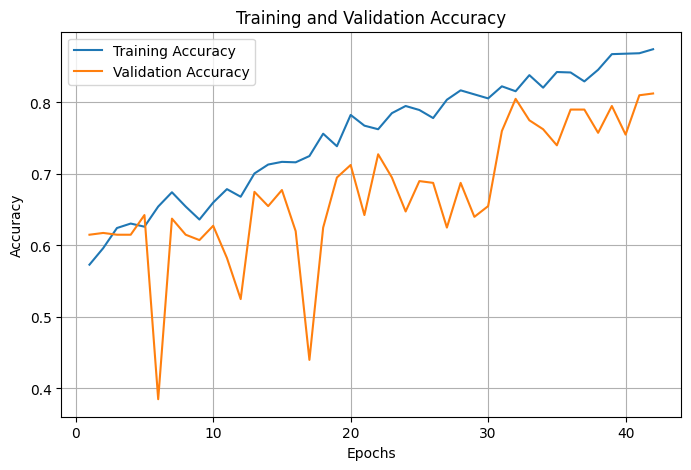

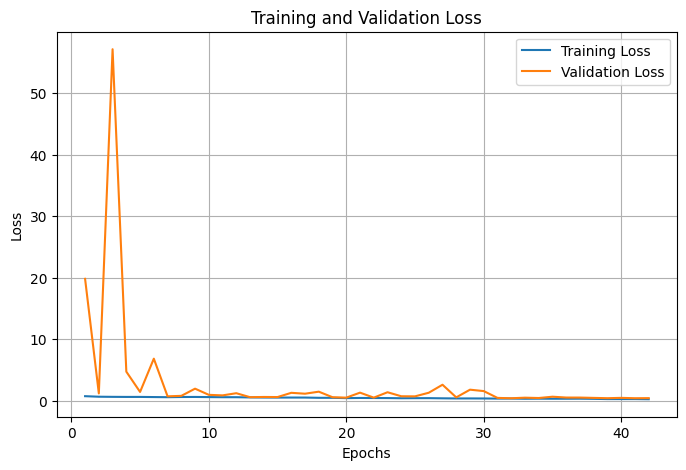

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Train and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Train and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
model = kr.models.load_model("/content/drive/MyDrive/Projects/stroke classification project/model.dens121.h5")

In [16]:
model.evaluate(test_df)

16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.8303 - loss: 0.4537


[0.453698068857193, 0.8303393125534058]

In [17]:
y_prob = model.predict(test_df)
y_pred = (y_prob >= 0.2).astype(int)
y_pred = y_pred.flatten()
print(classification_report(y_test , y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step
              precision    recall  f1-score   support

           0       0.92      0.70      0.80       311
           1       0.65      0.89      0.75       190

    accuracy                           0.78       501
   macro avg       0.78      0.80      0.77       501
weighted avg       0.81      0.78      0.78       501



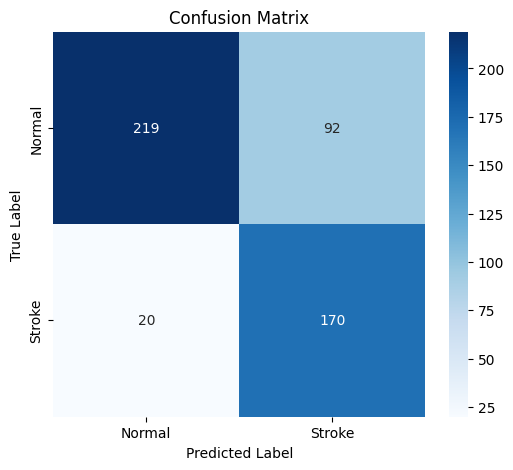

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Stroke'],
            yticklabels=['Normal', 'Stroke'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
model.save("/content/drive/MyDrive/Projects/stroke classification project/model.dens121.h5", save_format="h5")

In [ ]:
model.save_weights("/content/drive/MyDrive/Projects/stroke classification project/model.weights.h5")